# Emotion Classification with Attention

## 0. Setup & Installs

In [1]:
!pip install -q datasets evaluate transformers accelerate contractions


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00


In [2]:
import os, re, json, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, GRU, Bidirectional, Dense, Dropout, Input, Layer
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TF version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Stage 1 — Dataset Preparation
Source: https://huggingface.co/datasets/google-research-datasets/go_emotions

In [3]:
from datasets import load_dataset

raw = load_dataset('google-research-datasets/go_emotions', 'simplified')
print(raw)
label_names = raw['train'].features['labels'].feature.names
print(len(label_names), 'raw labels:', label_names)


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})
28 raw labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [4]:
train_df = raw['train'].to_pandas()
val_df   = raw['validation'].to_pandas()
test_df  = raw['test'].to_pandas()

for df in (train_df, val_df, test_df):
    df['labels'] = df['labels'].apply(list)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()


(43410, 3) (5426, 3) (5427, 3)


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [5]:
print(train_df.isna().sum())
print('Empty text rows:', (train_df['text'].str.strip() == '').sum())


text      0
labels    0
id        0
dtype: int64
Empty text rows: 0


### Map GoEmotions' 27 fine-grained labels -> 6 core emotions

In [6]:
EMOTION_MAP = {
    'admiration': None, 'amusement': 'joy', 'anger': 'anger', 'annoyance': 'anger',
    'approval': None, 'caring': None, 'confusion': None, 'curiosity': None,
    'desire': None, 'disappointment': 'sadness', 'disapproval': None,
    'disgust': 'disgust', 'embarrassment': None, 'excitement': 'joy',
    'fear': 'fear', 'gratitude': 'joy', 'grief': 'sadness', 'joy': 'joy',
    'love': 'joy', 'nervousness': 'fear', 'optimism': None, 'pride': 'joy',
    'realization': None, 'relief': None, 'remorse': 'sadness', 'sadness': 'sadness',
    'surprise': 'surprise', 'neutral': None,
}
TARGET_EMOTIONS = ['joy', 'sadness', 'anger', 'fear', 'surprise', 'disgust']
label2id = {e: i for i, e in enumerate(TARGET_EMOTIONS)}
id2label = {i: e for e, i in label2id.items()}

def map_row_labels(label_ids):
    mapped = set()
    for lid in label_ids:
        name = label_names[lid]
        target = EMOTION_MAP.get(name)
        if target is not None:
            mapped.add(target)
    return mapped

def build_clean_df(df):
    mapped = df['labels'].apply(map_row_labels)
    keep = mapped.apply(lambda s: len(s) == 1)
    out = df[keep].copy()
    out['emotion'] = mapped[keep].apply(lambda s: next(iter(s)))
    out['label_id'] = out['emotion'].map(label2id)
    return out[['text', 'emotion', 'label_id']].reset_index(drop=True)

train_clean = build_clean_df(train_df)
val_clean   = build_clean_df(val_df)
test_clean  = build_clean_df(test_df)

print('Train/Val/Test sizes after mapping:', len(train_clean), len(val_clean), len(test_clean))
train_clean.head()


Train/Val/Test sizes after mapping: 16661 2041 2053


,text,emotion,label_id
0,WHY THE FUCK IS BAYLESS ISOING,anger,2
1,To make her feel threatened,fear,3
2,Dirty Southern Wankers,anger,2
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,surprise,4
4,Yes I heard abt the f bombs! That has to be wh...,joy,0


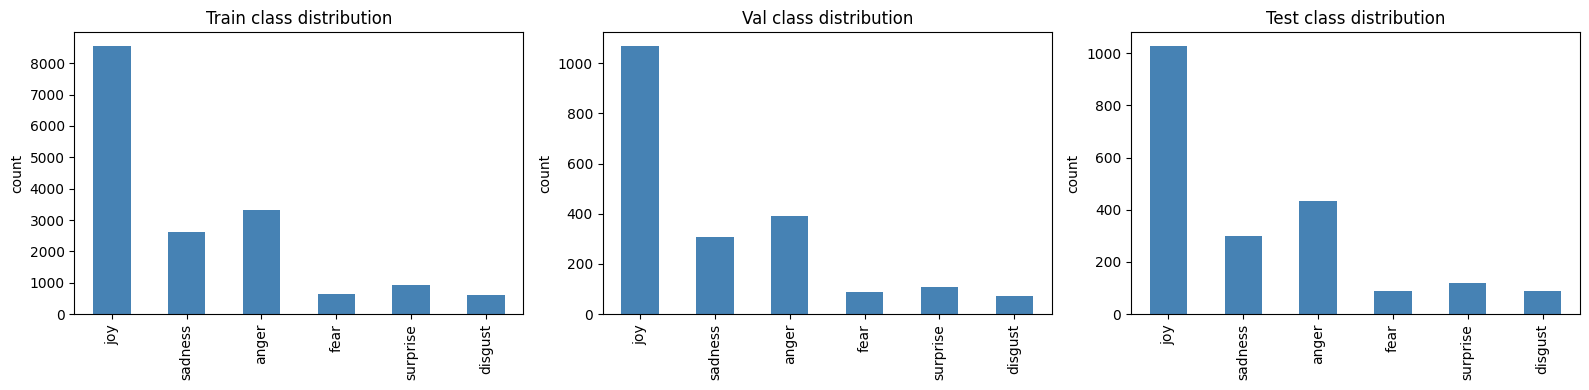

emotion
joy         8558
anger       3328
sadness     2608
surprise     922
fear         638
disgust      607
Name: count, dtype: int64

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16,4))
for a, (name, d) in zip(ax, [('Train', train_clean), ('Val', val_clean), ('Test', test_clean)]):
    d['emotion'].value_counts().reindex(TARGET_EMOTIONS).plot(kind='bar', ax=a, color='steelblue')
    a.set_title(f'{name} class distribution')
    a.set_xlabel(''); a.set_ylabel('count')
plt.tight_layout(); plt.show()

train_clean['emotion'].value_counts()


## Stage 2 — Text Preprocessing

In [8]:
import contractions

URL_RE = re.compile(r'https?://\S+|www\.\S+')
HTML_RE = re.compile(r'<.*?>')
MULTI_SPACE_RE = re.compile(r'\s+')

def clean_text(text):
    text = str(text).lower()
    text = URL_RE.sub(' ', text)
    text = HTML_RE.sub(' ', text)
    text = contractions.fix(text)
    text = text.replace('[NAME]', ' ').replace('[RELIGION]', ' ')
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = MULTI_SPACE_RE.sub(' ', text).strip()
    return text

for d in (train_clean, val_clean, test_clean):
    d['clean_text'] = d['text'].apply(clean_text)

train_clean = train_clean[train_clean['clean_text'].str.len() > 0].reset_index(drop=True)
val_clean   = val_clean[val_clean['clean_text'].str.len() > 0].reset_index(drop=True)
test_clean  = test_clean[test_clean['clean_text'].str.len() > 0].reset_index(drop=True)

train_clean[['text','clean_text','emotion']].head()


,text,clean_text,emotion
0,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,anger
1,To make her feel threatened,to make her feel threatened,fear
2,Dirty Southern Wankers,dirty southern wankers,anger
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,omg peyton is not good enough to help us in th...,surprise
4,Yes I heard abt the f bombs! That has to be wh...,yes i heard about the f bombs that has to be w...,joy


In [9]:
MAX_VOCAB = 20000
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(train_clean['clean_text'])

def to_padded(df):
    seq = tokenizer.texts_to_sequences(df['clean_text'])
    return pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_train = to_padded(train_clean)
X_val   = to_padded(val_clean)
X_test  = to_padded(test_clean)

y_train = train_clean['label_id'].values
y_val   = val_clean['label_id'].values
y_test  = test_clean['label_id'].values

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print('Vocab size:', vocab_size)
print('X_train shape:', X_train.shape)

class_weights_arr = compute_class_weight('balanced', classes=np.arange(6), y=y_train)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print(class_weights)


Vocab size: 14694
X_train shape: (16661, 40)
{0: np.float64(0.32447222871387393), 1: np.float64(1.0647367075664622), 2: np.float64(0.8343850160256411), 3: np.float64(4.352403343782654), 4: np.float64(3.0117498192335503), 5: np.float64(4.574684239428885)}


## Stage 3 — Word Embeddings (GloVe)

In [10]:
GLOVE_CANDIDATES = [
    '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt',
    '/kaggle/input/glove-global-vectors-for-word-representation/glove.6B.100d.txt',
]
GLOVE_PATH = next((p for p in GLOVE_CANDIDATES if os.path.exists(p)), None)

if GLOVE_PATH is None:
    print('GloVe not found as Kaggle input dataset. Downloading...')
    os.system('wget -q http://nlp.stanford.edu/data/glove.6B.zip')
    os.system('unzip -q -o glove.6B.zip glove.6B.100d.txt')
    GLOVE_PATH = 'glove.6B.100d.txt'

print('Using GloVe file:', GLOVE_PATH)


GloVe not found as Kaggle input dataset. Downloading...
Using GloVe file: glove.6B.100d.txt


In [11]:
EMBED_DIM = 100
embeddings_index = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vec = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vec
print('Loaded', len(embeddings_index), 'word vectors')

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hits = 0
for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    vec = embeddings_index.get(word)
    if vec is not None:
        embedding_matrix[i] = vec
        hits += 1
print(f'Embedding coverage: {hits}/{vocab_size} ({hits/vocab_size:.1%})')


Loaded 400000 word vectors
Embedding coverage: 13079/14694 (89.0%)


## Stage 4 — Build Deep Learning Models

In [12]:
def make_embedding_layer(trainable=False):
    return Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                      weights=[embedding_matrix], input_length=MAX_LEN,
                      trainable=trainable, mask_zero=True)

def compile_model(model):
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model

EPOCHS = 12
BATCH_SIZE = 128
callbacks = [EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]


### Model 1 — LSTM

In [13]:
lstm_model = Sequential([
    make_embedding_layer(),
    LSTM(128, dropout=0.3, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])
lstm_model = compile_model(lstm_model)
lstm_model.summary()


I0000 00:00:1784743087.742726      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784743087.745944      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,469,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,469,400 (5.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,469,400 (5.61 MB)

In [14]:
history_lstm = lstm_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights,
    callbacks=callbacks, verbose=1
)


Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 26s 143ms/step - accuracy: 0.3002 - loss: 1.7328 - val_accuracy: 0.4802 - val_loss: 1.4721
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 138ms/step - accuracy: 0.4592 - loss: 1.5399 - val_accuracy: 0.5488 - val_loss: 1.2477
Epoch 3/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - accuracy: 0.5307 - loss: 1.3706 - val_accuracy: 0.6624 - val_loss: 1.0009
Epoch 4/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 136ms/step - accuracy: 0.5860 - loss: 1.2172 - val_accuracy: 0.7006 - val_loss: 0.8870
Epoch 5/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - accuracy: 0.6274 - loss: 1.1045 - val_accuracy: 0.7202 - val_loss: 0.8498
Epoch 6/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 134ms/step - accuracy: 0.6516 - loss: 1.0347 - val_accuracy: 0.7207 - val_loss: 0.8134
Epoch 7/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - accuracy: 0.6782 - loss: 0.9670 - val_accuracy: 0.7389 - val_loss: 0.7711
Epoch 8/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.6950 - loss: 0

### Model 2 — GRU

In [15]:
gru_model = Sequential([
    make_embedding_layer(),
    GRU(128, dropout=0.3, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])
gru_model = compile_model(gru_model)
history_gru = gru_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights,
    callbacks=callbacks, verbose=1
)


Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.2776 - loss: 1.7268 - val_accuracy: 0.3503 - val_loss: 1.6395
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 15s 115ms/step - accuracy: 0.4365 - loss: 1.5319 - val_accuracy: 0.5169 - val_loss: 1.2351


### Model 3 — BiLSTM + Attention

In [16]:
class AttentionLayer(Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.W = self.add_weight(name='att_W', shape=(input_shape[-1], self.units),
                                  initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='att_b', shape=(self.units,),
                                  initializer='zeros', trainable=True)
        self.u = self.add_weight(name='att_u', shape=(self.units, 1),
                                  initializer='glorot_uniform', trainable=True)
        super().build(input_shape)

    def call(self, hidden_states, mask=None):
        score = K.tanh(K.dot(hidden_states, self.W) + self.b)
        score = K.dot(score, self.u)
        score = K.squeeze(score, axis=-1)
        if mask is not None:
            score = tf.where(mask, score, -1e9 * tf.ones_like(score))
        weights = tf.nn.softmax(score, axis=1)
        weights_exp = tf.expand_dims(weights, axis=-1)
        context = tf.reduce_sum(hidden_states * weights_exp, axis=1)
        return context, weights

    def compute_mask(self, inputs, mask=None):
        return None

inp = Input(shape=(MAX_LEN,))
emb = make_embedding_layer()(inp)
bilstm_out = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2))(emb)
context, att_weights = AttentionLayer(64)(bilstm_out)
x = Dense(64, activation='relu')(context)
x = Dropout(0.3)(x)
out = Dense(6, activation='softmax')(x)

bilstm_att_model = Model(inputs=inp, outputs=out)
bilstm_att_model = compile_model(bilstm_att_model)
bilstm_att_model.summary()

bilstm_att_with_weights = Model(inputs=inp, outputs=[out, att_weights])


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 40, 100)   │  1,469,400 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 40)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 40, 256)   │    234,496 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ [(None, 256),     │     16,512 │ bidirectional[0]… │
│ (AttentionLayer)    │ (None, 40)]       │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ attention_layer[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 6)         │        390 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,737,246 (6.63 MB)

 Trainable params: 267,846 (1.02 MB)

 Non-trainable params: 1,469,400 (5.61 MB)

In [17]:
history_bilstm_att = bilstm_att_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights,
    callbacks=callbacks, verbose=1
)


Epoch 1/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 35s 211ms/step - accuracy: 0.4445 - loss: 1.5559 - val_accuracy: 0.6737 - val_loss: 1.0170
Epoch 2/12
131/131 ━━━━━━━━━━━━━━━━━━━━ 27s 203ms/step - accuracy: 0.6755 - loss: 1.0534 - val_accuracy: 0.7330 - val_loss: 0.8259


### Model 4 — Fine-tuned DistilBERT (HuggingFace)

In [18]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset
import evaluate

MODEL_NAME = 'distilbert-base-uncased'
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(df):
    return Dataset.from_pandas(df[['clean_text', 'label_id']].rename(columns={'clean_text':'text','label_id':'label'}))

hf_train = to_hf_dataset(train_clean)
hf_val   = to_hf_dataset(val_clean)
hf_test  = to_hf_dataset(test_clean)

def tokenize_fn(batch):
    return hf_tokenizer(batch['text'], truncation=True, max_length=64)

hf_train = hf_train.map(tokenize_fn, batched=True)
hf_val   = hf_val.map(tokenize_fn, batched=True)
hf_test  = hf_test.map(tokenize_fn, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=6, id2label=id2label, label2id=label2id
)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/16661 [00:00<?, ? examples/s]

Map:   0%|          | 0/2041 [00:00<?, ? examples/s]

Map:   0%|          | 0/2053 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)['accuracy']
    f1 = f1_metric.compute(predictions=preds, references=labels, average='macro')['f1']
    return {'accuracy': acc, 'macro_f1': f1}

training_args = TrainingArguments(
    output_dir='./distilbert_emotion',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='macro_f1',
    logging_steps=100,
    report_to='none',
)

import inspect
trainer_kwargs = dict(
    model=bert_model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer_params = inspect.signature(Trainer.__init__).parameters
if 'processing_class' in trainer_params:
    trainer_kwargs['processing_class'] = hf_tokenizer
else:
    trainer_kwargs['tokenizer'] = hf_tokenizer

trainer = Trainer(**trainer_kwargs)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.257736,0.961789,0.852033,0.723937
2,0.874361,0.864144,0.861832,0.766213
3,0.732383,0.848042,0.870162,0.780865


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=783, training_loss=1.0713186105701353, metrics={'train_runtime': 128.0276, 'train_samples_per_second': 390.408, 'train_steps_per_second': 6.116, 'total_flos': 414706094616348.0, 'train_loss': 1.0713186105701353, 'epoch': 3.0})

## Stage 5 — Model Evaluation

--- LSTM ---
Accuracy: 0.7526 | Macro F1: 0.6674
              precision    recall  f1-score   support

         joy       0.94      0.83      0.88      1029
     sadness       0.68      0.66      0.67       298
       anger       0.71      0.63      0.67       432
        fear       0.65      0.71      0.68        87
    surprise       0.44      0.82      0.57       119
     disgust       0.42      0.76      0.54        88

    accuracy                           0.75      2053
   macro avg       0.64      0.73      0.67      2053
weighted avg       0.79      0.75      0.76      2053



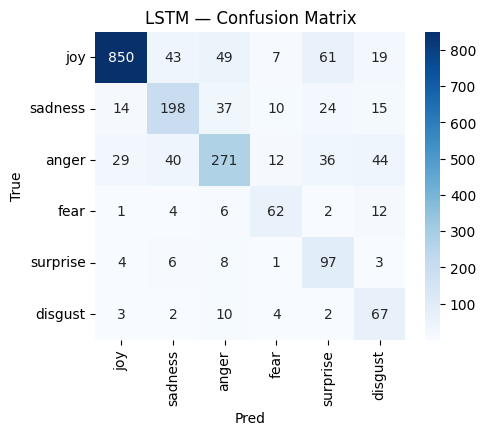

--- GRU ---
Accuracy: 0.3376 | Macro F1: 0.2739
              precision    recall  f1-score   support

         joy       0.85      0.40      0.55      1029
     sadness       0.38      0.23      0.29       298
       anger       0.56      0.16      0.25       432
        fear       0.14      0.29      0.19        87
    surprise       0.09      0.50      0.15       119
     disgust       0.13      0.62      0.22        88

    accuracy                           0.34      2053
   macro avg       0.36      0.37      0.27      2053
weighted avg       0.61      0.34      0.39      2053



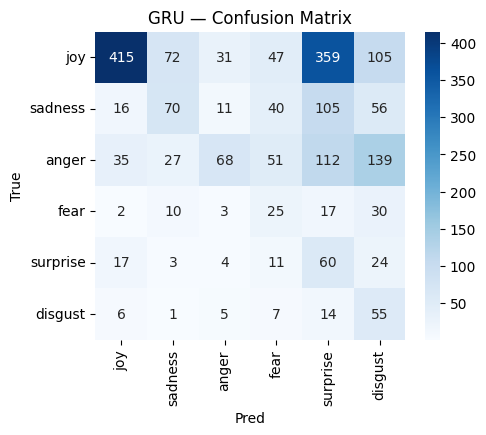

--- BiLSTM + Attention ---
Accuracy: 0.6693 | Macro F1: 0.5511
              precision    recall  f1-score   support

         joy       0.90      0.80      0.84      1029
     sadness       0.79      0.44      0.57       298
       anger       0.67      0.49      0.57       432
        fear       0.29      0.71      0.41        87
    surprise       0.39      0.65      0.49       119
     disgust       0.29      0.82      0.42        88

    accuracy                           0.67      2053
   macro avg       0.56      0.65      0.55      2053
weighted avg       0.75      0.67      0.69      2053



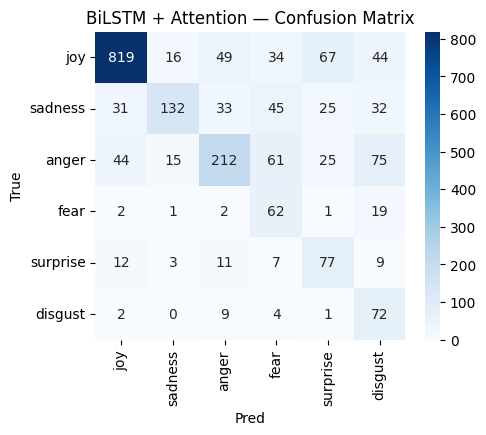

In [20]:
def evaluate_keras_model(model, X, y, name):
    probs = model.predict(X, batch_size=256, verbose=0)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(y, preds)
    macro_f1 = f1_score(y, preds, average='macro')
    print(f'--- {name} ---')
    print(f'Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}')
    print(classification_report(y, preds, target_names=TARGET_EMOTIONS))
    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_EMOTIONS, yticklabels=TARGET_EMOTIONS)
    plt.title(f'{name} — Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Pred')
    plt.show()
    return {'model': name, 'accuracy': acc, 'macro_f1': macro_f1}

results = []
results.append(evaluate_keras_model(lstm_model, X_test, y_test, 'LSTM'))
results.append(evaluate_keras_model(gru_model, X_test, y_test, 'GRU'))
results.append(evaluate_keras_model(bilstm_att_model, X_test, y_test, 'BiLSTM + Attention'))


DistilBERT — Accuracy: 0.8441 | Macro F1: 0.7415
              precision    recall  f1-score   support

         joy       0.95      0.96      0.95      1029
     sadness       0.74      0.75      0.74       298
       anger       0.78      0.77      0.77       432
        fear       0.67      0.74      0.70        87
    surprise       0.71      0.71      0.71       119
     disgust       0.68      0.50      0.58        88

    accuracy                           0.84      2053
   macro avg       0.75      0.74      0.74      2053
weighted avg       0.84      0.84      0.84      2053



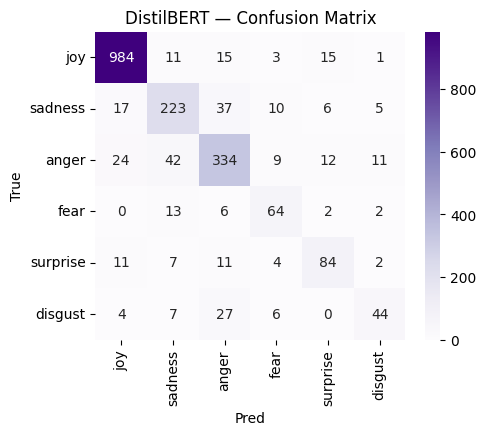

In [21]:
bert_preds_output = trainer.predict(hf_test)
bert_preds = np.argmax(bert_preds_output.predictions, axis=1)
bert_labels = bert_preds_output.label_ids

bert_acc = accuracy_score(bert_labels, bert_preds)
bert_f1 = f1_score(bert_labels, bert_preds, average='macro')
print(f'DistilBERT — Accuracy: {bert_acc:.4f} | Macro F1: {bert_f1:.4f}')
print(classification_report(bert_labels, bert_preds, target_names=TARGET_EMOTIONS))

cm = confusion_matrix(bert_labels, bert_preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=TARGET_EMOTIONS, yticklabels=TARGET_EMOTIONS)
plt.title('DistilBERT — Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Pred')
plt.show()

results.append({'model': 'DistilBERT', 'accuracy': bert_acc, 'macro_f1': bert_f1})


In [22]:
comparison_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
comparison_df


,model,accuracy,macro_f1
0,DistilBERT,0.844131,0.741454
1,LSTM,0.752557,0.667397
2,BiLSTM + Attention,0.669264,0.551059
3,GRU,0.337555,0.273861


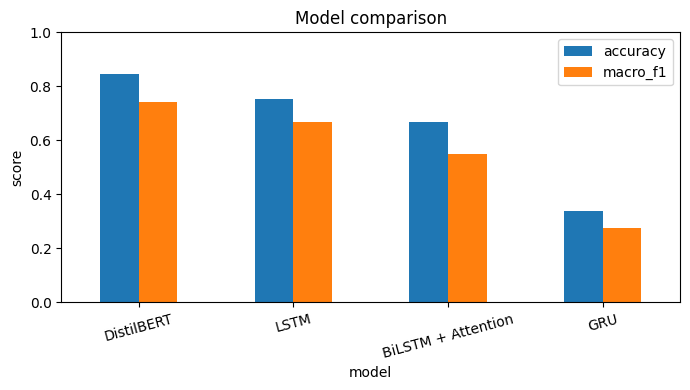

Best model by macro F1: DistilBERT


In [23]:
comparison_df.plot(x='model', y=['accuracy', 'macro_f1'], kind='bar', figsize=(7,4), rot=15)
plt.title('Model comparison'); plt.ylabel('score'); plt.ylim(0,1); plt.tight_layout(); plt.show()

best_model_name = comparison_df.iloc[0]['model']
print('Best model by macro F1:', best_model_name)


## Stage 6 — Attention Visualization

Sentence: "I am extremely happy today."
Predicted emotion: joy (confidence 75.39%)


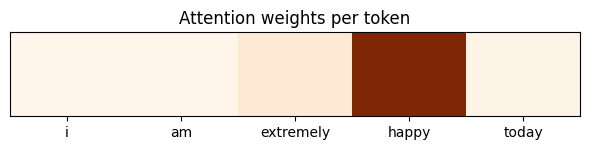

Sentence: "This makes me so angry and disgusted."
Predicted emotion: fear (confidence 45.27%)


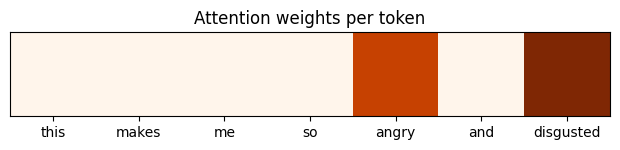

Sentence: "I am terrified of what might happen next."
Predicted emotion: fear (confidence 75.79%)


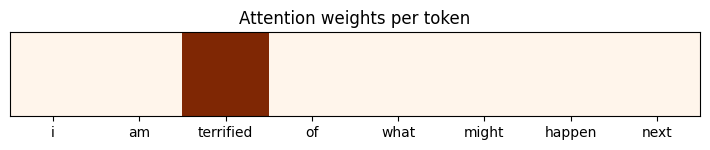

In [24]:
def visualize_attention(sentence, model_with_weights=bilstm_att_with_weights, max_len=MAX_LEN):
    clean = clean_text(sentence)
    seq = tokenizer.texts_to_sequences([clean])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    probs, weights = model_with_weights.predict(padded, verbose=0)
    probs, weights = probs[0], weights[0]

    tokens = clean.split()
    n = len(tokens)
    w = weights[:n]
    w = w / (w.sum() + 1e-9)

    pred_id = int(np.argmax(probs))
    print(f'Sentence: "{sentence}"')
    print(f'Predicted emotion: {id2label[pred_id]} (confidence {probs[pred_id]:.2%})')

    fig, ax = plt.subplots(figsize=(max(6, n*0.9), 1.6))
    ax.imshow(w[np.newaxis, :], cmap='Oranges', aspect='auto')
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=0)
    ax.set_yticks([])
    ax.set_title('Attention weights per token')
    plt.tight_layout(); plt.show()

    return dict(zip(tokens, w.tolist()))

_ = visualize_attention('I am extremely happy today.')
_ = visualize_attention('This makes me so angry and disgusted.')
_ = visualize_attention('I am terrified of what might happen next.')


## Stage 7 (part 1) — Export Artifacts for Deployment

In [25]:
ART_DIR = '/kaggle/working/deployment_artifacts'
os.makedirs(ART_DIR, exist_ok=True)

bilstm_att_model.save(os.path.join(ART_DIR, 'bilstm_attention_model.keras'))

bert_model.save_pretrained(os.path.join(ART_DIR, 'distilbert_emotion'))
hf_tokenizer.save_pretrained(os.path.join(ART_DIR, 'distilbert_emotion'))

with open(os.path.join(ART_DIR, 'keras_tokenizer.json'), 'w') as f:
    f.write(tokenizer.to_json())

config = {
    'label2id': label2id,
    'id2label': id2label,
    'max_len': MAX_LEN,
    'embed_dim': EMBED_DIM,
    'vocab_size': vocab_size,
}
with open(os.path.join(ART_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

comparison_df.to_csv(os.path.join(ART_DIR, 'model_comparison.csv'), index=False)

print('Saved artifacts to', ART_DIR)
for root, dirs, files in os.walk(ART_DIR):
    for fn in files:
        print(os.path.join(root, fn))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved artifacts to /kaggle/working/deployment_artifacts
/kaggle/working/deployment_artifacts/keras_tokenizer.json
/kaggle/working/deployment_artifacts/model_comparison.csv
/kaggle/working/deployment_artifacts/config.json
/kaggle/working/deployment_artifacts/bilstm_attention_model.keras
/kaggle/working/deployment_artifacts/distilbert_emotion/model.safetensors
/kaggle/working/deployment_artifacts/distilbert_emotion/tokenizer_config.json
/kaggle/working/deployment_artifacts/distilbert_emotion/config.json
/kaggle/working/deployment_artifacts/distilbert_emotion/tokenizer.json
